# 🪖 Hard Hat Detection — YOLOv8 Training on Google Colab

**Dataset:** [Hard Hat Detection](https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection) (Pascal VOC format)  
**Model:** YOLOv8 (Ultralytics)  
**Classes:** `helmet` · `head` · `person`

> ⚡ Trước khi chạy: **Runtime → Change runtime type → T4 GPU**


## 🔧 Cell 1 — Kiểm tra GPU

In [ ]:
import torch, subprocess

gpu = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(gpu.stdout if gpu.returncode == 0 else "Không có GPU — hãy đổi runtime!")
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Thu Apr  2 03:51:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 📦 Cell 2 — Cài thư viện

In [ ]:
%pip install ultralytics kaggle -q
from ultralytics import YOLO
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.33


## 🔑 Cell 3 — Kết nối Kaggle API

**Cách lấy `kaggle.json`:**
1. Vào https://www.kaggle.com → Account → **Create New Token**
2. File `kaggle.json` sẽ tải về máy
3. Upload file đó vào Colab (click vào ô code bên dưới rồi chạy)


In [ ]:
from google.colab import files
import os, json

# Upload kaggle.json
uploaded = files.upload()  # chọn file kaggle.json từ máy tính

# Cài đặt credentials
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded['kaggle.json'])
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Verify
with open('/root/.kaggle/kaggle.json') as f:
    creds = json.load(f)
print(f"✅ Đăng nhập Kaggle với username: {creds['username']}")


Saving kaggle.json to kaggle.json
✅ Đăng nhập Kaggle với username: sinhvny


## 📥 Cell 4 — Tải dataset từ Kaggle

In [ ]:
import os

# Cấu hình lại đường dẫn gốc cho đúng với thực tế thư mục của bạn
DATASET_DIR = '/content'

# 1. Tải và giải nén nếu chưa thấy thư mục annotations
if not os.path.exists(f'{DATASET_DIR}/annotations'):
    !kaggle datasets download -d andrewmvd/hard-hat-detection -p /content/ --unzip
    print("✅ Download và giải nén xong!")
else:
    print("Dataset đã tồn tại, bỏ qua download.")

# 2. Kiểm tra số lượng file để đảm bảo đường dẫn đã chuẩn
try:
    imgs = len(list(os.scandir(f'{DATASET_DIR}/images')))
    lbls = len(list(os.scandir(f'{DATASET_DIR}/annotations')))
    print(f"📊 Kết quả -> Ảnh: {imgs} | Annotations: {lbls}")
except FileNotFoundError as e:
    print(f"❌ Lỗi: Không tìm thấy thư mục. Chi tiết: {e}")
    !ls -F /content/

Dataset đã tồn tại, bỏ qua download.
📊 Kết quả -> Ảnh: 5000 | Annotations: 5000


## 🔄 Cell 5 — Convert Pascal VOC → YOLO format & chia train/val/test

In [ ]:
import os, shutil, random, yaml, cv2
import xml.etree.ElementTree as ET
from pathlib import Path

# ── Cấu hình ──────────────────────────────────────
# ── Cấu hình lại cho đúng thực tế ──────────────────────
DATASET_RAW  = '/content'          # Thay đổi từ '/content/hard-hat-detection'
DATASET_YOLO = '/content/dataset_yolo'
TRAIN_RATIO  = 0.80
VAL_RATIO    = 0.15
CLASSES      = ['helmet', 'head', 'person']
# ... các dòng code phía sau giữ nguyên ...
CLASS_MAP    = {c: i for i, c in enumerate(CLASSES)}
random.seed(42)

# ── Convert 1 XML → YOLO lines ─────────────────────
def voc_to_yolo(xml_path, img_w, img_h):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    lines = []
    for obj in root.findall('object'):
        name = obj.find('name').text.strip().lower()
        if name not in CLASS_MAP:
            continue
        bb = obj.find('bndbox')
        xmin = float(bb.find('xmin').text)
        ymin = float(bb.find('ymin').text)
        xmax = float(bb.find('xmax').text)
        ymax = float(bb.find('ymax').text)
        xmin, xmax = max(0, xmin), min(img_w, xmax)
        ymin, ymax = max(0, ymin), min(img_h, ymax)
        cx = ((xmin + xmax) / 2) / img_w
        cy = ((ymin + ymax) / 2) / img_h
        w  = (xmax - xmin) / img_w
        h  = (ymax - ymin) / img_h
        if w > 0 and h > 0:
            lines.append(f"{CLASS_MAP[name]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
    return lines

# ── Collect pairs ───────────────────────────────────
img_dir = Path(DATASET_RAW) / 'images'
ann_dir = Path(DATASET_RAW) / 'annotations'
pairs = []
for xml in sorted(ann_dir.glob('*.xml')):
    for ext in ['.png', '.jpg', '.jpeg']:
        img = img_dir / (xml.stem + ext)
        if img.exists():
            pairs.append((img, xml))
            break

print(f"Tổng cặp ảnh-annotation: {len(pairs)}")
random.shuffle(pairs)
n = len(pairs)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
splits  = {'train': pairs[:n_train],
           'val':   pairs[n_train:n_train+n_val],
           'test':  pairs[n_train+n_val:]}

# ── Copy & convert ──────────────────────────────────
for split, ps in splits.items():
    (Path(DATASET_YOLO) / split / 'images').mkdir(parents=True, exist_ok=True)
    (Path(DATASET_YOLO) / split / 'labels').mkdir(parents=True, exist_ok=True)
    ok = 0
    for img_path, xml_path in ps:
        img = cv2.imread(str(img_path))
        if img is None: continue
        h, w = img.shape[:2]
        lines = voc_to_yolo(xml_path, w, h)
        if not lines: continue
        shutil.copy2(img_path, Path(DATASET_YOLO) / split / 'images' / img_path.name)
        (Path(DATASET_YOLO) / split / 'labels' / (img_path.stem + '.txt')).write_text('\n'.join(lines))
        ok += 1
    print(f"  [{split:5s}] {ok} ảnh")

# ── Tạo data.yaml ───────────────────────────────────
data_yaml = {
    'path':  DATASET_YOLO,
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc':    len(CLASSES),
    'names': CLASSES,
}
yaml_path = f'{DATASET_YOLO}/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(f"\n✅ data.yaml: {yaml_path}")

# Hiện nội dung
!cat {yaml_path}


Tổng cặp ảnh-annotation: 5000
  [train] 4000 ảnh
  [val  ] 750 ảnh
  [test ] 250 ảnh

✅ data.yaml: /content/dataset_yolo/data.yaml
path: /content/dataset_yolo
train: train/images
val: val/images
test: test/images
nc: 3
names:
- helmet
- head
- person


## 🖼️ Cell 6 — Xem mẫu dữ liệu (tuỳ chọn)

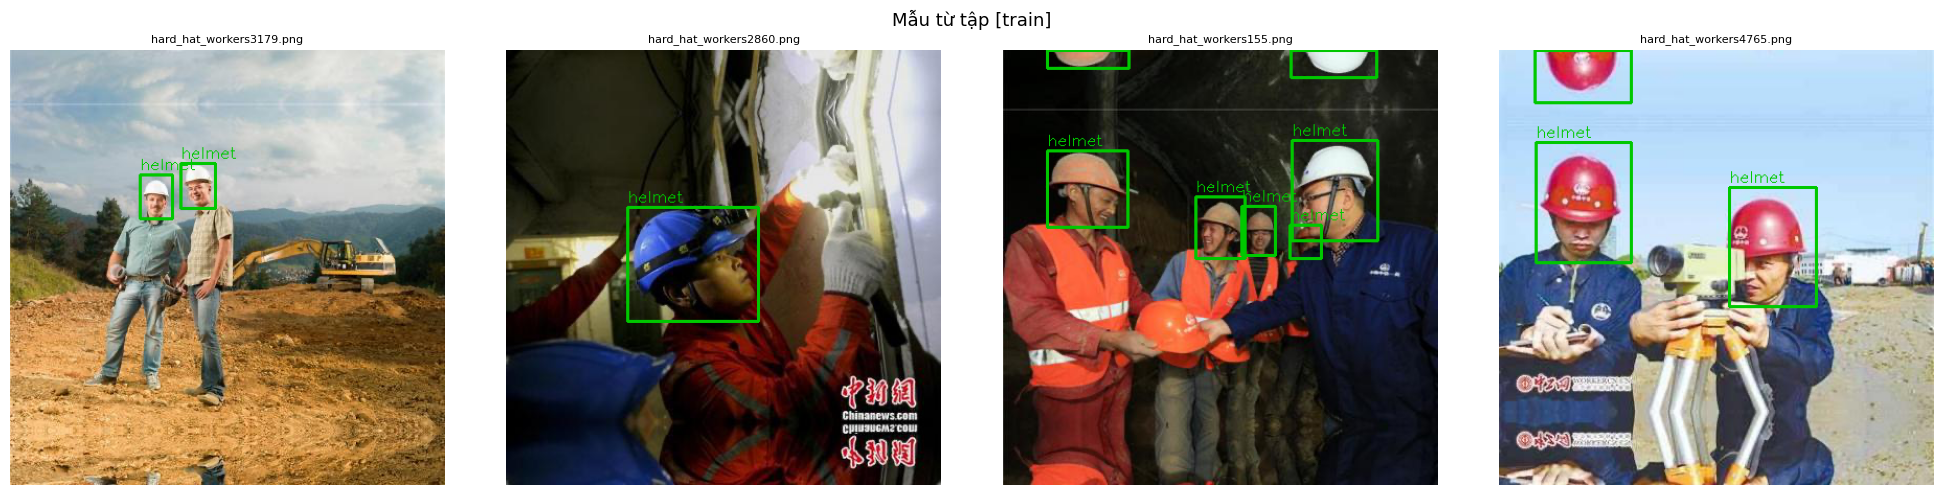

In [ ]:
import cv2, random, matplotlib.pyplot as plt
from pathlib import Path

COLORS = [(0,200,0), (0,0,220), (220,130,0)]   # helmet, head, person
NAMES  = ['helmet', 'head', 'person']

def show_sample(split='train', n=4):
    img_dir = Path(DATASET_YOLO) / split / 'images'
    imgs = list(img_dir.glob('*.png')) + list(img_dir.glob('*.jpg'))
    sample = random.sample(imgs, min(n, len(imgs)))
    fig, axes = plt.subplots(1, len(sample), figsize=(5*len(sample), 5))
    if len(sample) == 1: axes = [axes]
    for ax, ip in zip(axes, sample):
        img = cv2.cvtColor(cv2.imread(str(ip)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lp = ip.parent.parent / 'labels' / (ip.stem + '.txt')
        if lp.exists():
            for line in lp.read_text().strip().split('\n'):
                cls, cx, cy, bw, bh = map(float, line.split())
                cls = int(cls)
                x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
                c  = tuple(reversed(COLORS[cls]))
                cv2.rectangle(img, (x1,y1), (x2,y2), c, 2)
                cv2.putText(img, NAMES[cls], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, c, 1)
        ax.imshow(img); ax.axis('off'); ax.set_title(ip.name, fontsize=8)
    plt.suptitle(f'Mẫu từ tập [{split}]', fontsize=13)
    plt.tight_layout(); plt.show()

show_sample('train', 4)


## ⚙️ Cell 7 — Cấu hình training

Chỉnh các tham số tại đây trước khi train:


In [ ]:
# ════════════════════════════════════════
#   CHỈNH THAM SỐ TẠI ĐÂY
# ════════════════════════════════════════

MODEL   = 'yolov8n.pt'   # n | s | m | l | x  (n=nhanh nhất, x=chính xác nhất)
EPOCHS  = 50             # số epoch (Colab free: 50-100 là đủ)
IMGSZ   = 640            # kích thước ảnh
BATCH   = 16             # giảm xuống 8 nếu bị OOM
LR0     = 0.01           # learning rate ban đầu
PATIENCE= 15             # early stopping (dừng nếu không cải thiện sau N epoch)
PROJECT = '/content/runs'
NAME    = 'hardhat_yolov8'

print("Cấu hình training:")
print(f"  Model   : {MODEL}")
print(f"  Epochs  : {EPOCHS}")
print(f"  Img size: {IMGSZ}")
print(f"  Batch   : {BATCH}")
print(f"  Device  : GPU (T4)" if torch.cuda.is_available() else "  Device  : CPU ⚠️")


Cấu hình training:
  Model   : yolov8n.pt
  Epochs  : 50
  Img size: 640
  Batch   : 16
  Device  : GPU (T4)


## 🚀 Cell 8 — Train mô hình

In [ ]:
from ultralytics import YOLO

model = YOLO(MODEL)

results = model.train(
    data      = yaml_path,
    epochs    = EPOCHS,
    imgsz     = IMGSZ,
    batch     = BATCH,
    lr0       = LR0,
    lrf       = 0.01,
    patience  = PATIENCE,
    optimizer = 'SGD',
    project   = PROJECT,
    name      = NAME,
    device    = 0 if torch.cuda.is_available() else 'cpu',
    # Augmentation
    degrees   = 5.0,
    translate = 0.1,
    scale     = 0.5,
    fliplr    = 0.5,
    mosaic    = 1.0,
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,
    # Logging
    plots     = True,
    save      = True,
    save_period = 10,
    verbose   = True,
)

print("\n✅ Training hoàn tất!")
BEST_PT = f'{PROJECT}/{NAME}/weights/best.pt'
print(f"Best model: {BEST_PT}")


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolo/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hardhat_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=15, persp

## 📊 Cell 9 — Xem kết quả training

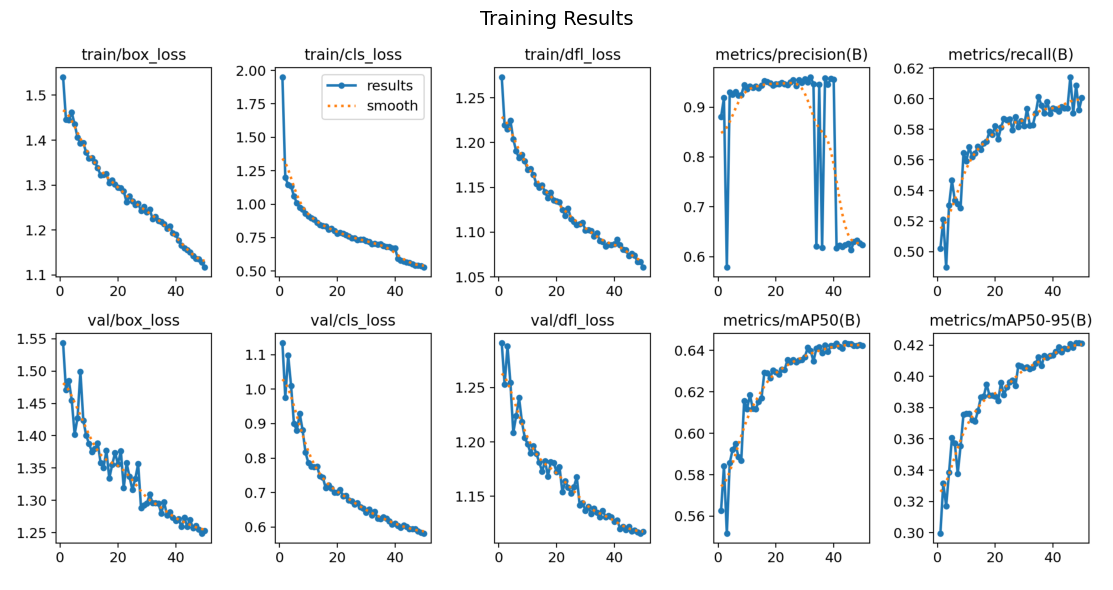

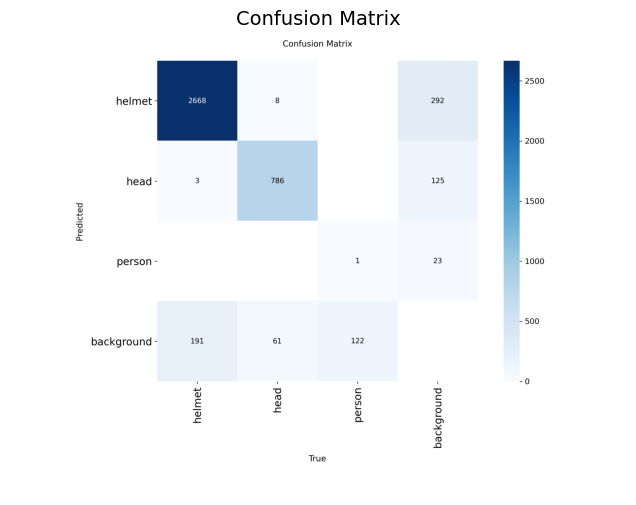

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

run_dir = Path(PROJECT) / NAME

# Hiện results.png (loss + metrics theo epoch)
result_img = run_dir / 'results.png'
if result_img.exists():
    img = mpimg.imread(str(result_img))
    plt.figure(figsize=(18, 6))
    plt.imshow(img); plt.axis('off')
    plt.title('Training Results', fontsize=14)
    plt.tight_layout(); plt.show()

# Confusion matrix
cm_img = run_dir / 'confusion_matrix.png'
if cm_img.exists():
    img = mpimg.imread(str(cm_img))
    plt.figure(figsize=(8, 6))
    plt.imshow(img); plt.axis('off')
    plt.title('Confusion Matrix', fontsize=14)
    plt.show()

# PR Curve
pr_img = run_dir / 'PR_curve.png'
if pr_img.exists():
    img = mpimg.imread(str(pr_img))
    plt.figure(figsize=(8, 6))
    plt.imshow(img); plt.axis('off')
    plt.title('PR Curve', fontsize=14)
    plt.show()


## 🧪 Cell 10 — Đánh giá trên tập test

In [ ]:
from ultralytics import YOLO

best_model = YOLO(BEST_PT)
metrics = best_model.val(data=yaml_path, split='test', verbose=True)

print("\n" + "="*45)
print("  KẾT QUẢ TRÊN TẬP TEST")
print("="*45)
print(f"  mAP@50     : {metrics.box.map50:.4f}")
print(f"  mAP@50-95  : {metrics.box.map:.4f}")
print(f"  Precision  : {metrics.box.mp:.4f}")
print(f"  Recall     : {metrics.box.mr:.4f}")
print("="*45)

# Per-class
for i, name in enumerate(CLASSES):
    try:
        ap = metrics.box.ap[i]
        print(f"  {name:10s}  AP50: {metrics.box.ap50[i]:.3f}  AP: {ap:.3f}")
    except:
        pass


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3822.9±775.7 MB/s, size: 260.0 KB)
val: Scanning /content/dataset_yolo/test/labels... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 1.2Kit/s 0.2s
val: New cache created: /content/dataset_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.8it/s 5.6s
                   all        250       1224      0.946       0.58      0.623      0.417
                helmet        225        872       0.92      0.907       0.95      0.641
                  head         48        322      0.918      0.834      0.903      0.599
                person          7         30          1          0      0.017    0.00955
Speed: 3.7ms preprocess, 4.9ms inference, 0.0ms loss, 1.9ms postprocess per 

## 🔍 Cell 11 — Inference trên ảnh test

/tmp/ipykernel_872/3716543493.py:65: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


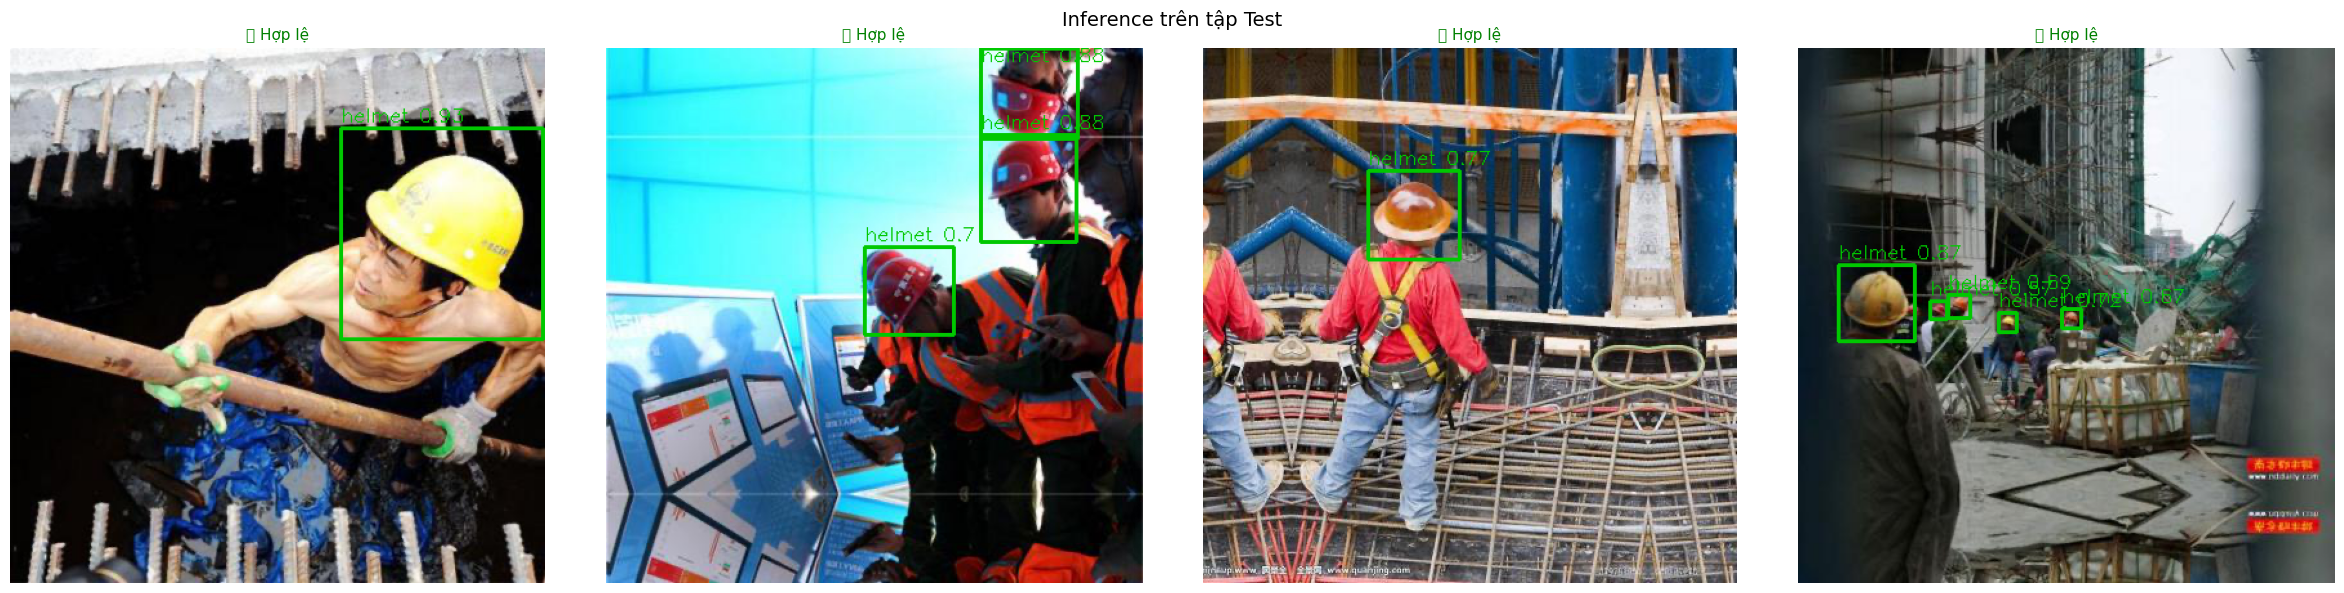

In [ ]:
import random, cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

COLORS_BGR = [(0,200,0), (0,0,220), (220,130,0)]   # helmet, head, person
CONF_THRESH = 0.45

best_model = YOLO(BEST_PT)

# Lấy ngẫu nhiên 4 ảnh từ test set
test_imgs = list((Path(DATASET_YOLO) / 'test' / 'images').glob('*.png'))
test_imgs += list((Path(DATASET_YOLO) / 'test' / 'images').glob('*.jpg'))
sample = random.sample(test_imgs, min(4, len(test_imgs)))

fig, axes = plt.subplots(1, len(sample), figsize=(6*len(sample), 6))
if len(sample) == 1: axes = [axes]

for ax, img_path in zip(axes, sample):
    results = best_model.predict(str(img_path), conf=CONF_THRESH, verbose=False)
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    violation = False
    heads, helmets = [], []

    for box in results[0].boxes:
        cls_id = int(box.cls)
        conf   = float(box.conf)
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        if cls_id == 1: heads.append((x1,y1,x2,y2))
        if cls_id == 0: helmets.append((x1,y1,x2,y2))

    # Check violation
    if heads:
        violation = not helmets or True  # simplified check
        for hd in heads:
            covered = any(
                max(0, min(hd[2],hm[2]) - max(hd[0],hm[0])) > 0 and
                max(0, min(hd[3],hm[3]) - max(hd[1],hm[1])) > 0
                for hm in helmets
            )
            if not covered:
                violation = True

    for box in results[0].boxes:
        cls_id = int(box.cls)
        conf   = float(box.conf)
        x1,y1,x2,y2 = map(int, box.xyxy[0].tolist())
        color = tuple(reversed(COLORS_BGR[cls_id]))
        label = f"{CLASSES[cls_id]} {conf:.2f}"
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        cv2.putText(img, label, (x1, max(y1-5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    if violation:
        cv2.putText(img, "CANH BAO!", (10, h-15),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255,0,0), 3)

    ax.imshow(img); ax.axis('off')
    title = "⚠️ Vi phạm!" if violation else "✅ Hợp lệ"
    ax.set_title(title, fontsize=11, color='red' if violation else 'green')

plt.suptitle('Inference trên tập Test', fontsize=14)
plt.tight_layout(); plt.show()


## 💾 Cell 12 — Export model & tải về máy

In [ ]:
from ultralytics import YOLO
from google.colab import files
import shutil

best_model = YOLO(BEST_PT)

# Export ONNX
print("Đang export ONNX...")
best_model.export(format='onnx', imgsz=IMGSZ, simplify=True)
onnx_path = BEST_PT.replace('.pt', '.onnx')
print(f"✅ ONNX: {onnx_path}")

# Nén thư mục weights + kết quả
run_dir  = f'{PROJECT}/{NAME}'
zip_name = f'/content/{NAME}_results'
shutil.make_archive(zip_name, 'zip', run_dir)
print(f"✅ ZIP: {zip_name}.zip")

# Download
print("\nChọn file để tải về:")
print("1. best.pt    — PyTorch weight")
print("2. best.onnx  — ONNX weight (deploy)")
print("3. ZIP toàn bộ kết quả")

files.download(BEST_PT)
# files.download(onnx_path)
# files.download(f'{zip_name}.zip')


Đang export ONNX...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/hardhat_yolov8/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 257ms
Prepared 4 packages in 5.50s
Installed 4 packages in 306ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 6.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 op

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ☁️ Cell 13 — Lưu lên Google Drive (tuỳ chọn)

In [ ]:
from google.colab import drive
import shutil, os, glob

# 1. Kết nối Drive
drive.mount('/content/drive')

DRIVE_DEST = '/content/drive/MyDrive/HardHat_YOLOv8'
os.makedirs(DRIVE_DEST, exist_ok=True)

# 2. Xác định đường dẫn weights chính xác
weights_dir = f'{PROJECT}/{NAME}/weights'
best_weight = f'{weights_dir}/best.pt'
last_weight = f'{weights_dir}/last.pt'

# 3. Copy weights (Kiểm tra file tồn tại trước khi copy)
if os.path.exists(best_weight):
    shutil.copy(best_weight, f'{DRIVE_DEST}/best.pt')
    print(f"✅ Đã lưu: best.pt")

if os.path.exists(last_weight):
    shutil.copy(last_weight, f'{DRIVE_DEST}/last.pt')
    print(f"✅ Đã lưu: last.pt")
else:
    print(f"⚠️ Không tìm thấy file last.pt tại {last_weight}")

# 4. Copy các file kết quả (.png, .csv, .yaml)
for f in glob.glob(f'{PROJECT}/{NAME}/*.png') + glob.glob(f'{PROJECT}/{NAME}/*.csv'):
    shutil.copy(f, DRIVE_DEST)

print(f"\n⭐ Tất cả dữ liệu đã được đồng bộ tại: {DRIVE_DEST}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Đã lưu: best.pt
✅ Đã lưu: last.pt

⭐ Tất cả dữ liệu đã được đồng bộ tại: /content/drive/MyDrive/HardHat_YOLOv8
